<Figure size 1000x600 with 0 Axes>

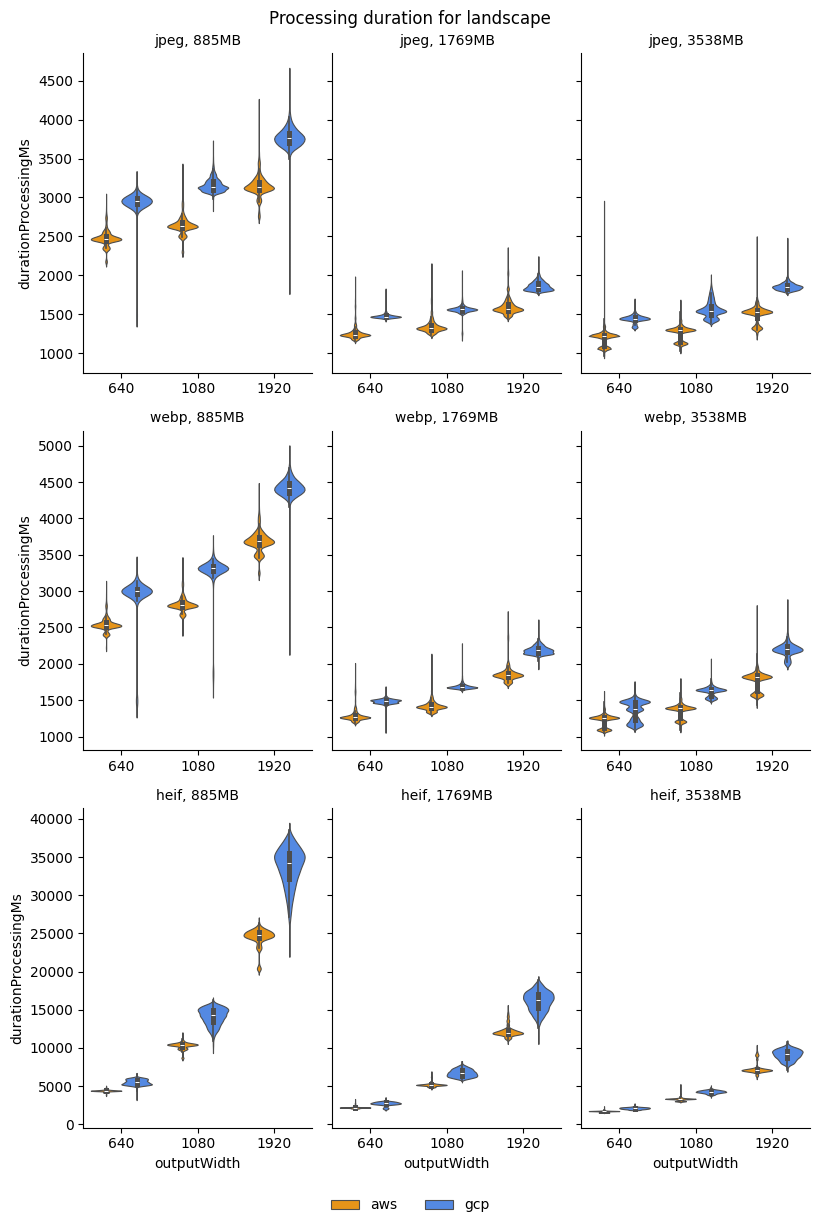

<Figure size 1000x600 with 0 Axes>

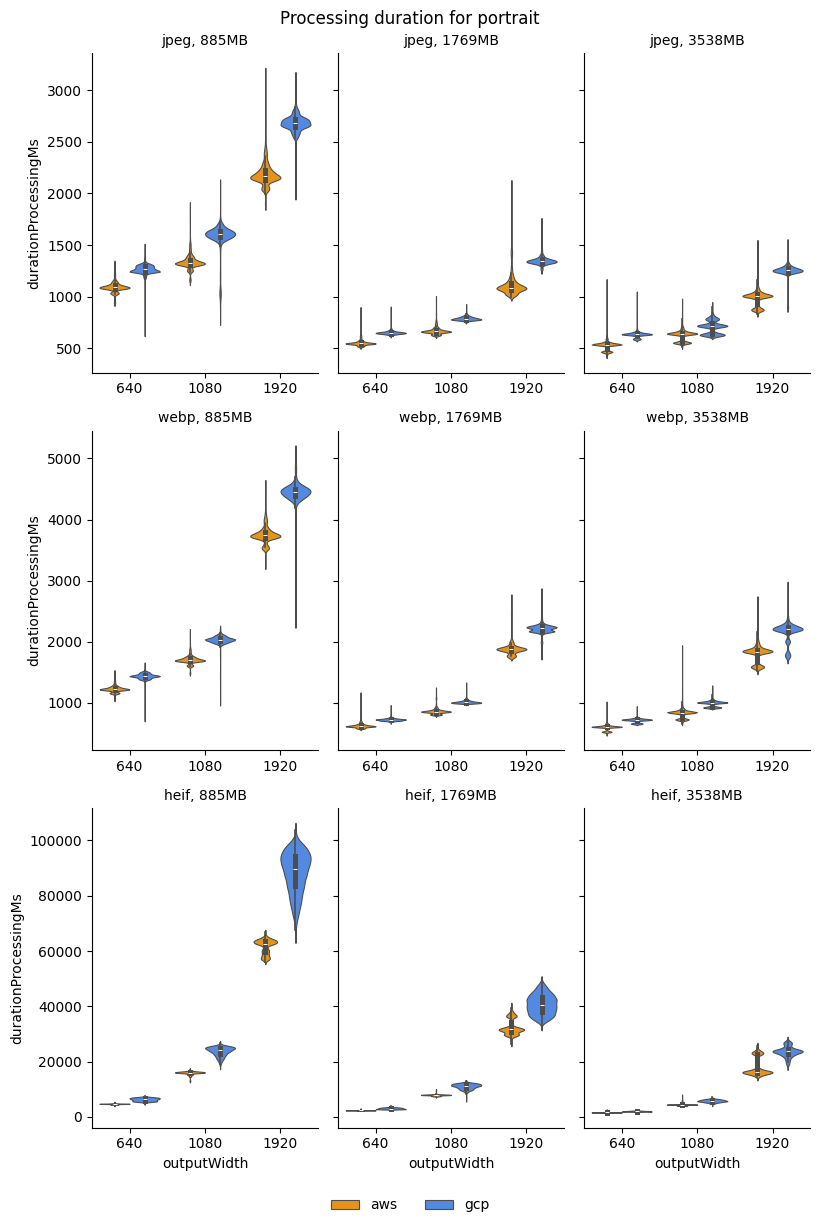

In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

pd.set_option('display.width', 1000)
palette = {'aws': '#ff9900', 'gcp': '#4285F4'}
df = pd.read_pickle('../stats-all-latest.pkl')
# df = df.loc[(df["timestamp"] > 1733011200000+86400000*7)]

for imageName in ["landscape", "portrait"]:
    data = df.loc[(df["imageName"] == imageName)]

    # Calculate quantiles for each group
    # def remove_outliers(group):
    #     lower = group['durationProcessingMs'].quantile(0.025)
    #     upper = group['durationProcessingMs'].quantile(0.975)
    #     return group[(group['durationProcessingMs'] >= lower) & (group['durationProcessingMs'] <= upper)]

    # data = data.groupby(['outputWidth', 'providerMemoryAssociated', 'outputFormat', 'providerName']).apply(remove_outliers).reset_index(drop=True)

    plt.figure(figsize=(10, 6))

    ax = sns.catplot(
        kind='violin',
        x='outputWidth',
        y='durationProcessingMs',
        col='providerMemoryAssociated',
        row='outputFormat',
        hue='providerName',
        data=data,
        height=4,
        aspect=0.6,
        sharex=False,
        sharey='row',
        saturation=0.8,
        dodge=True,
        hue_order=['aws', 'gcp'],
        row_order=['jpeg', 'webp', 'heif'],
        linewidth=0.8,
        density_norm='count',
        palette=palette,
    )
    # sns.move_legend(ax, "upper right", ncol=2)
    # sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 0.5))
    sns.move_legend(ax, loc='upper center', bbox_to_anchor=(0.5, 0), title=None, ncol=2)
    ax.set_titles("{row_name}, {col_name}MB")
    plt.suptitle(f'Processing duration for {imageName}')
    plt.tight_layout()
    ax.savefig(f'../graphs/2-duration-comparison-{imageName}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()